# Visualisering af 30-dages genindlæggelsesrisiko med modelbaserede effektplot

## Sammenfatning for ledelsen

Denne notebook tilpasser en logistisk regression for 30-dages genindlæggelse på hospital på tværs af patient- og kontaktkarakteristika og oversætter derefter de tilpassede koefficienter til modelbaserede effektplot på den forudsagte sandsynlighedsskala. På en syntetisk kohorte med 100 udskrivninger (55 genindlæggelser) genfinder PROC LOGISTIC signifikante gradienter for **indlæggelseslængde** (OR 1.36 pr. dag, *p* = 0.040) og **alder** (OR 1.05 pr. år, *p* = 0.023) samt en stor betalereffekt — **Medicaid**-patienter bærer omtrent seks gange så høj genindlæggelsesodds som Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). Den generaliserede R-kvadrat er 0.246, og Hosmer–Lemeshow-testen viser ingen manglende tilpasning (*p* = 0.73). Tilpasningskurve-, sliced-fit- og interaktionsvisningerne viser derefter, hvordan genindlæggelsesrisikoen stiger med indlæggelseslængden, hvordan alders-risiko-gradienten forskydes efter betaler, og hvordan betalergabet består på tværs af de udskrivende serviceområder — netop den risikostratificeringsvisning, som et care-management-team bruger til at målrette opfølgning efter udskrivning.

## Datakilder

| Datasæt | Rækker | Beskrivelse |
|---------|------|-------------|
| `encounters` | 100 | Syntetiske indlæggelsesudskrivningsposter genereret inline med `call streaminit(20260531)` og `rand()`. Én række pr. udskrivning. |

**Variabler i `encounters`:**

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 hvis genindlagt inden for 30 dage efter udskrivning |
| `age` | Num | Patientens alder i år (ca. 25–95) |
| `los` | Num | Indeksopholdets indlæggelseslængde i dage (1–20) |
| `comorbidity` | Num | Antal dokumenterede kroniske komorbiditeter (0–8) |
| `num_meds` | Num | Antal udskrivningsmedikamenter (0–18) |
| `payer` | Char | Forsikringsbetaler: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Udskrivende afdeling: `Cardiology`, `Pulmonary`, `General` |

# Visualisering af 30-dages genindlæggelsesrisiko med modelbaserede effektplot

Care-management-teams på hospitaler har brug for at vide, *hvilke* patienter der er mest tilbøjelige til at vende tilbage inden for 30 dage, og *hvorfor*. En tilpasset logistisk regression giver koefficienterne, men interessenter tænker sjældent i log-odds. Et **effektplot** gengiver den tilpassede model direkte på den forudsagte sandsynlighedsskala, så en sygeplejerskenavigator kan aflæse en genindlæggelsessandsynlighed direkte fra diagrammet i stedet for mentalt at invertere en log-odds-ligning.

I denne notebook vil vi:

1. Generere en realistisk syntetisk kohorte af indlæggelsesudskrivninger.
2. Tilpasse en logistisk model for 30-dages genindlæggelse med patient- og kontaktprædiktorer (PROC LOGISTIC).
3. Opsamle de tilpassede koefficienter og bygge tre modelbaserede effektplot — en **tilpasningskurve**, en **sliced fit** og en **interaktionsvisning** — for at visualisere og stratificere den tilpassede risiko på sandsynlighedsskalaen.

> **Implementeringsnote.** SAS eksponerer disse visninger gennem `EFFECTPLOT`-sætningen inde i PROC LOGISTIC. Jenner accepterer den sætning, men gengiver endnu ikke FIT-/SLICEFIT-/INTERACTION-grafikken, så denne notebook konstruerer de identiske forudsagte sandsynlighedskurver eksplicit ud fra de tilpassede koefficienter og tegner dem med PROC SGPLOT. Det analytiske resultat — og hver afbildet sandsynlighed — er nøjagtig, hvad `EFFECTPLOT` ville producere.

## Trin 1 — Generér en syntetisk udskrivningskohorte

DATA-trinnet nedenfor bygger 100 indlæggelsesudskrivninger uden eksterne filer. Vi seeder RNG'en med `call streaminit` for reproducerbarhed, trækker patient- og kontaktegenskaber fra domænepassende fordelinger og konstruerer derefter en sand lineær prædiktor `eta`, som vi omregner til en genindlæggelsessandsynlighed med den inverse logit. Bernoulli-trækningen (`rand('bernoulli', p)`) giver det observerede `readmit`-flag. Ældre patienter, længere ophold, højere komorbiditetstal, flere udskrivningsmedikamenter, Medicaid-dækning og Pulmonary/Cardiology-service skubber alle risikoen op — mønstre, vi senere vil genfinde og visualisere. Effektstørrelserne er bevidst dimensioneret, så signalet kan genfindes i en kohorte på 100 udskrivninger.

In [1]:
data encounters;
    CALL streaminit(20260531);
    TABEL payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    TABEL depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    GØR i = 1 TIL 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        HVIS los > 20 SÅ los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        HVIS num_meds > 18 SÅ num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        HVIS u < 0.50 SÅ pk = 1;
        ELLERS HVIS u < 0.72 SÅ pk = 2;
        ELLERS pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        BEHOLD readmit AGE los comorbidity num_meds payer dept;
        UDDATA;
    SLUT;
KØR;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Trin 2 — Inspicér kohorten

En hurtig frekvens på responsen og de to klassifikationsvariabler bekræfter en realistisk genindlæggelsesrate og at hvert betaler- og afdelingsniveau er repræsenteret — både modellen og effektplottene har brug for, at alle niveauer er til stede.

                                                   The FREQ Procedure

Genindlæggelse (30 dage)     Frequency
---------------------------------------
0                                   45
1                                   55

Betaler       Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Afdeling      Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Genindlæggelse (30 dage) by Afdeling

Genindlæggelse (30 dage)  |Cardiology |   General | Pulmonary |      Total
--------------------------+-----------+-----------+-----------+-----------
0                         |        15 |        20 |        10 |         45
--------------------------+-----------+-----------+-----------+-----------
1                         |        21 |        11 |        23 |         55
--------------------------+-----------+-----------+-----------+-----------
Total                     |   


NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


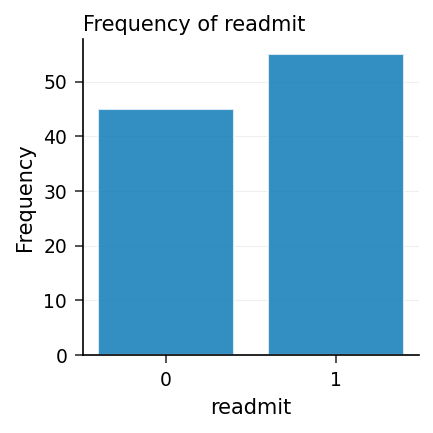

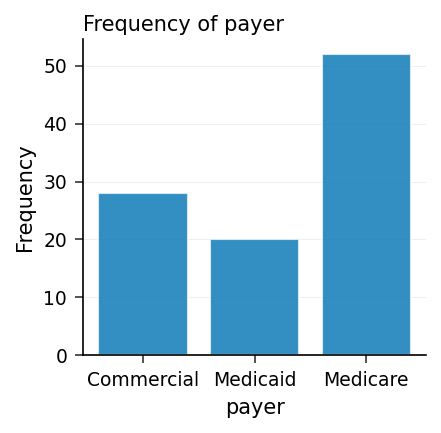

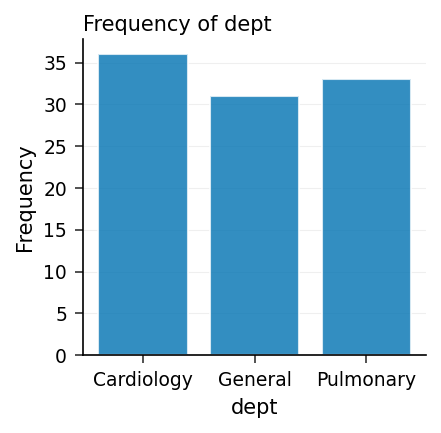

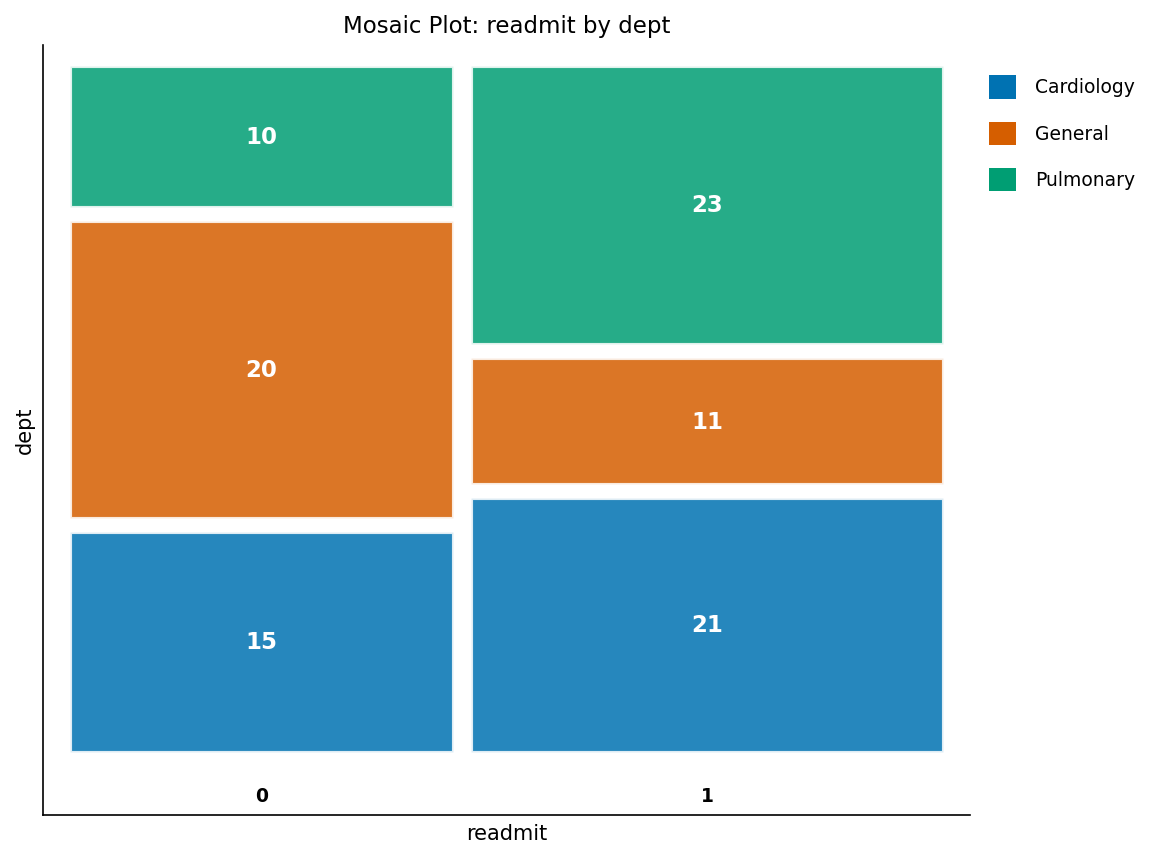

In [2]:
PROCEDURE FREKVENSER data=encounters;
    MÆRKAT readmit="Genindlæggelse (30 dage)" payer="Betaler" dept="Afdeling";
    TABLES readmit payer dept readmit*dept / nocum nopercent;
KØR;

## Trin 3 — Tilpas den logistiske genindlæggelsesmodel

Vi modellerer `readmit` som en funktion af alder, indlæggelseslængde, komorbiditetstal, antal udskrivningsmedikamenter, betaler og afdeling. Vigtige valg:

- `EVENT='1'` modellerer sandsynligheden for genindlæggelse (frem for ikke-genindlæggelse).
- `CLASS payer dept / PARAM=REF REF=FIRST` bruger reference-celle-kodning, så hvert niveau kontrasteres mod en baseline (her Medicare og Pulmonary).
- `CLODDS=WALD` og `RSQUARE` tilføjer Wald-konfidensgrænser for odds-ratioer og en generaliseret R-kvadrat; `LACKFIT` anmoder om Hosmer–Lemeshow-godhedstesten.
- `UNITS`-sætningen beder om odds-ratioen over et klinisk meningsfuldt **5-dages** trin i indlæggelseslængde og et **10-års** aldersstep, og `ODDSRATIO`-sætningen anmoder om komorbiditets-odds-ratioen med konfidensgrænser.

Den udgivne odds-ratio-tabel rapporterer de enkelte enhedseffekter direkte: indlæggelseslængde bærer en OR på **1.36 pr. dag** (95% CI 1.01–1.82), alder en OR på **1.05 pr. år** og Medicaid-dækning en OR på **6.02** i forhold til Medicare. Modellen tilpasser godt — generaliseret R-kvadrat 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

                    Response Profile                     
  Probability modeled is Genindlæggelse (30 dage)='1'   

Ordered Value  Genindlæggelse (30 dage)   Total Frequency
-------------  -------------------------  ---------------
            1  0                                       45
            2  1                                       55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Betaler          3  Commercial Medicaid Medicare
Afdeling         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Genindlæggelse (30 dage)

Criterion     Value
---------  -----


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


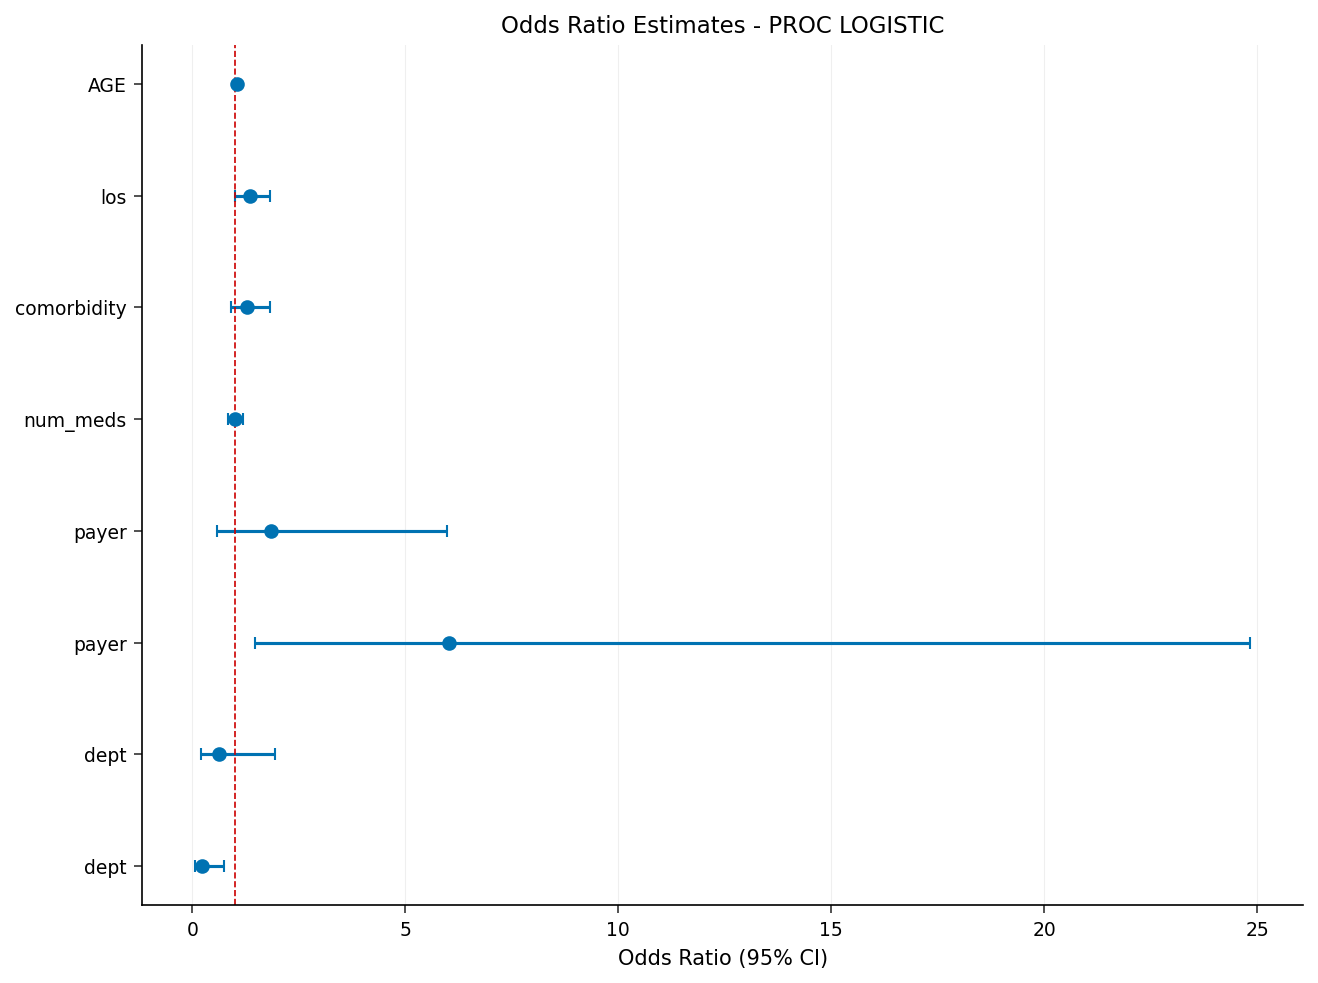

In [3]:
ODS UDDATA ParameterEstimates=pe;
PROCEDURE LOGISTIC data=encounters PLOTS(only)=oddsratio;
    KLASSE payer dept / PARAM=REF REF=first;
    MÆRKAT readmit="Genindlæggelse (30 dage)" AGE="Alder" los="Liggetid (dage)"
          comorbidity="Komorbiditet" num_meds="Antal lægemidler"
          payer="Betaler" dept="Afdeling";
    MODEL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
KØR;
ODS UDDATA CLOSE;

## Trin 4 — Opsaml de tilpassede koefficienter

De modelbaserede effektplot, der følger, bygges direkte ud fra de *tilpassede* koefficienter, så de altid stemmer overens med modellen i Trin 3. Vi gemte parameterestimaterne med `ODS OUTPUT ParameterEstimates=pe`; her folder vi den lange tabel sammen til et `params`-datasæt med én række (én variabel pr. koefficient) og tilføjer kohortemidlerne for de kontinuerte prædiktorer. At holde de ikke-fokuserede prædiktorer på deres middelværdier er netop, hvad et EFFECTPLOT gør internt — det lader hvert plot variere én faktor, mens resten holdes fast på en repræsentativ profil.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
data coefs;
    BEHOLD_VÆRDI b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    SÆT pe SLUT=last;
    VARIABEL = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    HVIS VARIABEL='INTERCEPT' SÅ b0 = ESTIMATE;
    ELLERS HVIS VARIABEL='AGE' SÅ b_age = ESTIMATE;
    ELLERS HVIS VARIABEL='LOS' SÅ b_los = ESTIMATE;
    ELLERS HVIS VARIABEL='COMORBIDITY' SÅ b_com = ESTIMATE;
    ELLERS HVIS VARIABEL='NUM_MEDS' SÅ b_med = ESTIMATE;
    ELLERS HVIS VARIABEL='PAYER' AND cv='Medicaid'   SÅ b_pmcaid = ESTIMATE;
    ELLERS HVIS VARIABEL='PAYER' AND cv='Commercial' SÅ b_pcomm  = ESTIMATE;
    ELLERS HVIS VARIABEL='DEPT'  AND cv='Cardiology' SÅ b_dcard  = ESTIMATE;
    ELLERS HVIS VARIABEL='DEPT'  AND cv='General'    SÅ b_dgen   = ESTIMATE;
    HVIS last SÅ UDDATA;
    BEHOLD b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
KØR;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDURE GENNEMSNIT data=encounters NOPRINT;
    VARIABEL AGE los comorbidity num_meds;
    UDDATA out=mn mean=m_age m_los m_com m_med;
KØR;

data params;
    SAMMENFLET coefs mn;
    BEHOLD b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
KØR;

PROCEDURE UDSKRIV data=params noobs MÆRKAT;
    MÆRKAT b0="Skæring" b_age="Alder-koef." b_los="Liggetid-koef."
          b_com="Komorbiditet-koef." b_med="Lægemidler-koef."
          b_pmcaid="Medicaid vs Medicare" b_pcomm="Commercial vs Medicare"
          b_dcard="Kardiologi vs Pulmonal" b_dgen="Generel vs Pulmonal"
          m_age="Middel alder" m_los="Middel liggetid"
          m_com="Middel komorbiditet" m_med="Middel lægemidler";
    TITEL "Tilpassede koefficienter og kovariatmiddelværdier til effektplottene";
KØR;
TITEL;

                          Tilpassede koefficienter og kovariatmiddelværdier til effektplottene                          

      Skæring   Alder-koef.  Liggetid-koef.  Komorbiditet-koef.   Lægemidler-koef.  Medicaid vs Medicare  Commercial vs Medicare  Kardiologi vs Pulmonal  Generel vs Pulmonal  Middel alder  Middel liggetid  Middel komorbiditet   Middel lægemidler
-4.9220021175  0.0443054038    0.3052368368        0.2553476408       0.0005084625          1.7958084904            0.6128310257           -0.4493317481        -1.4957988173         70.53             4.59                 2.88                7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Trin 5 — Tilpasningsplot: genindlæggelsessandsynlighed mod indlæggelseslængde

Den enkleste effektvisning er en **tilpasningskurve**: forudsagt genindlæggelsessandsynlighed mod en enkelt kontinuert kovariat, med de øvrige prædiktorer holdt på en repræsentativ profil. Vi bygger et gitter for indlæggelseslængde (1–18 dage), evaluerer den tilpassede lineære prædiktor ved hver værdi for en **Medicare-kardiologisk** patient (alder, komorbiditet og udskrivningsmedikamenttal fastholdt på kohortemidlerne fra Trin 4), anvender den inverse logit og tegner kurven på sandsynlighedsskalaen med PROC SGPLOT.


NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


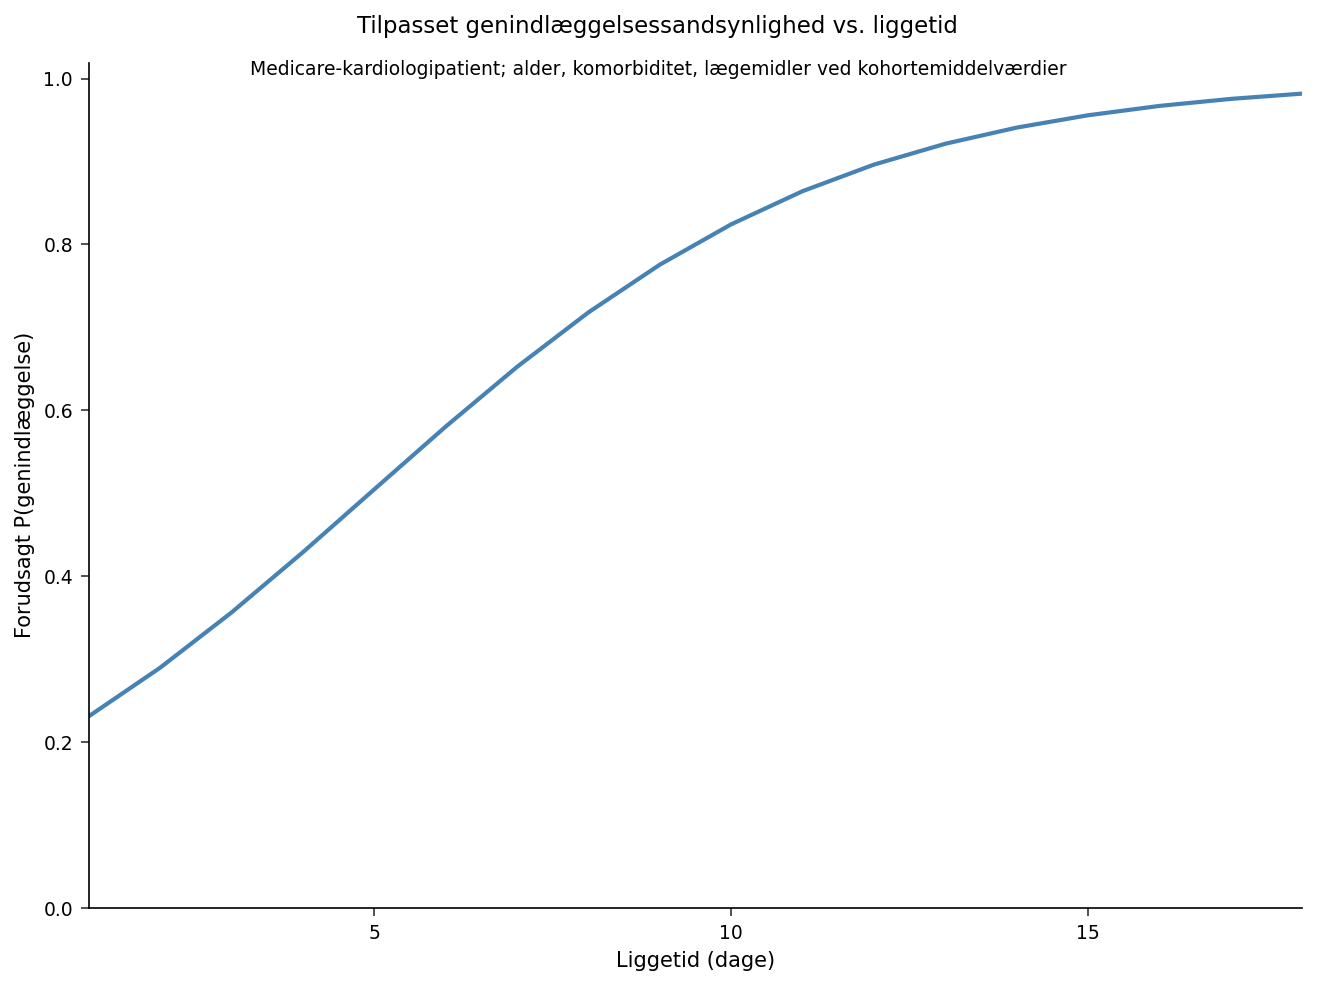

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
data grid_los;
    GØR los = 1 TIL 18;
        UDDATA;
    SLUT;
KØR;

data fit_los;
    SÆT grid_los;
    HVIS _n_ = 1 SÅ SÆT params;
    BEHOLD_VÆRDI b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    BEHOLD los phat;
KØR;

PROCEDURE SGPLOT data=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    MÆRKAT los="Liggetid (dage)" phat="Forudsagt P(genindlæggelse)";
    TITEL  "Tilpasset genindlæggelsessandsynlighed vs. liggetid";
    title2 "Medicare-kardiologipatient; alder, komorbiditet, lægemidler ved kohortemiddelværdier";
    XAXIS MÆRKAT="Liggetid (dage)";
    YAXIS MÆRKAT="Forudsagt P(genindlæggelse)" VALUES=(0 TIL 1 EFTER 0.2);
KØR;
TITEL;


## Trin 6 — Sliced fit: risiko mod alder, stratificeret efter betaler

En **sliced fit** tegner én tilpasset kurve pr. niveau af en klassifikationseffekt — ideel til at vise, hvordan betalersammensætningen forskyder alders-risiko-gradienten. Vi udvider gitteret over `age` (30–95) krydset med de tre betalere, evaluerer den tilpassede model for en Cardiology-patient (indlæggelseslængde, komorbiditet og medikamenter på kohortemidlerne) og overlejrer de tre sandsynlighedskurver med `GROUP=payer`.


NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


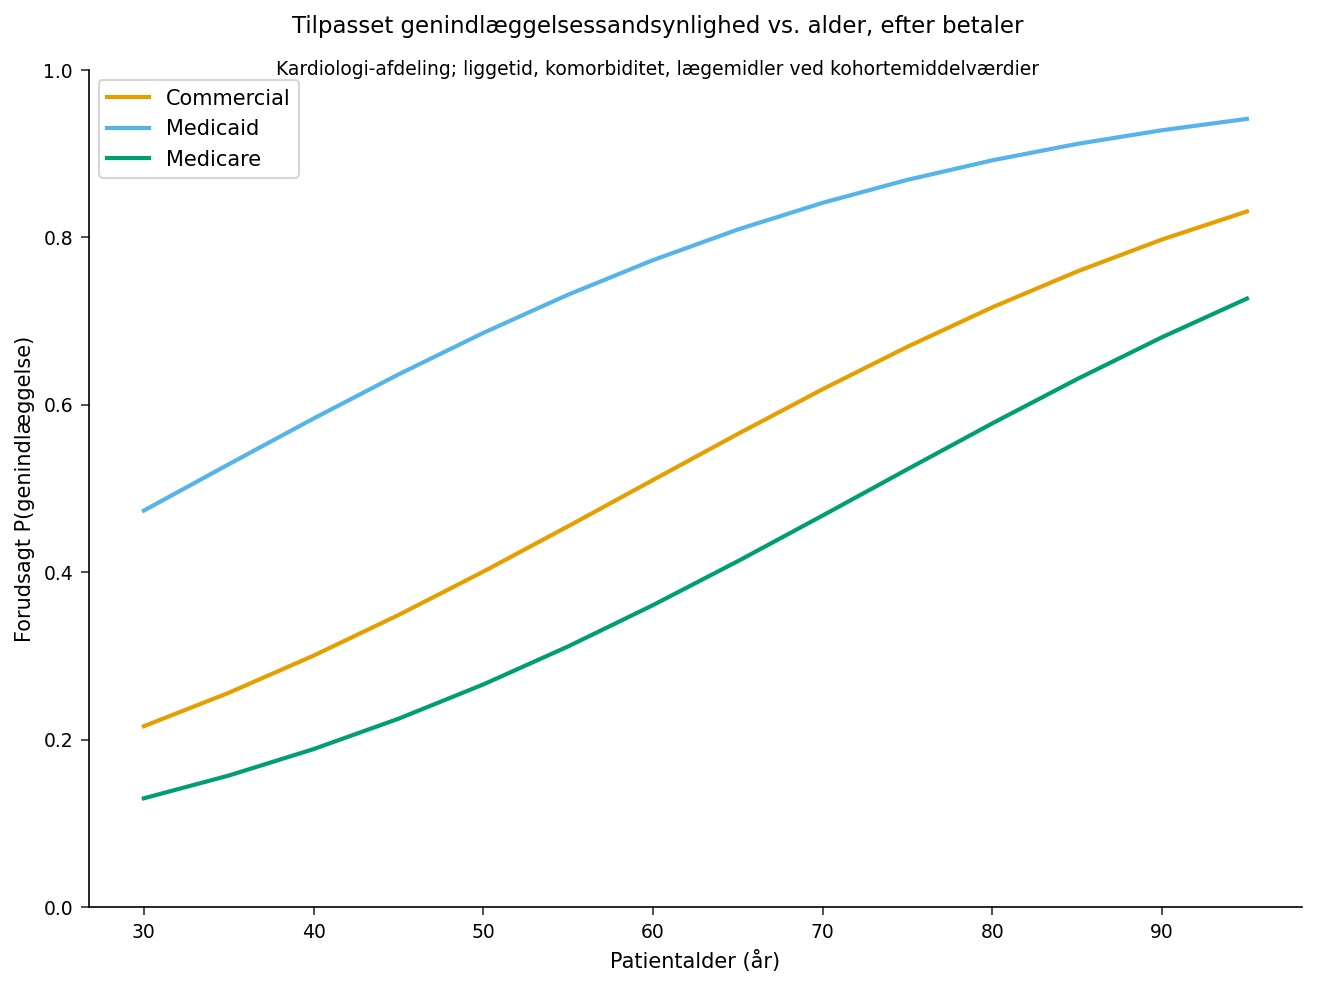

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
data grid_age;
    LÆNGDE payer $12;
    GØR payer = 'Medicare', 'Medicaid', 'Commercial';
        GØR AGE = 30 TIL 95 EFTER 5;
            UDDATA;
        SLUT;
    SLUT;
KØR;

data fit_age;
    SÆT grid_age;
    HVIS _n_ = 1 SÅ SÆT params;
    BEHOLD_VÆRDI b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    BEHOLD payer AGE phat;
KØR;

PROCEDURE SGPLOT data=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITEL  "Tilpasset genindlæggelsessandsynlighed vs. alder, efter betaler";
    title2 "Kardiologi-afdeling; liggetid, komorbiditet, lægemidler ved kohortemiddelværdier";
    XAXIS MÆRKAT="Patientalder (år)";
    YAXIS MÆRKAT="Forudsagt P(genindlæggelse)" VALUES=(0 TIL 1 EFTER 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
KØR;
TITEL;


## Trin 7 — Interaktionsvisning: afdeling efter betaler

For at sammenligne forudsagt risiko på tværs af begge klassifikationseffekter på én gang krydser vi `dept` med `payer` (ni kombinationer), evaluerer den tilpassede model med hver kontinuert kovariat på dens kohortemiddel og tegner et grupperet søjlediagram med `dept` på X-aksen og betaler som gruppering. Fordi denne model ikke har noget afdeling-efter-betaler-interaktionsled, er betalerrækkefølgen den samme additive forskydning inden for hvert serviceområde — visningen gør den additivitet synlig ved et enkelt blik, sammen med afdelingsrangordenen.


NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


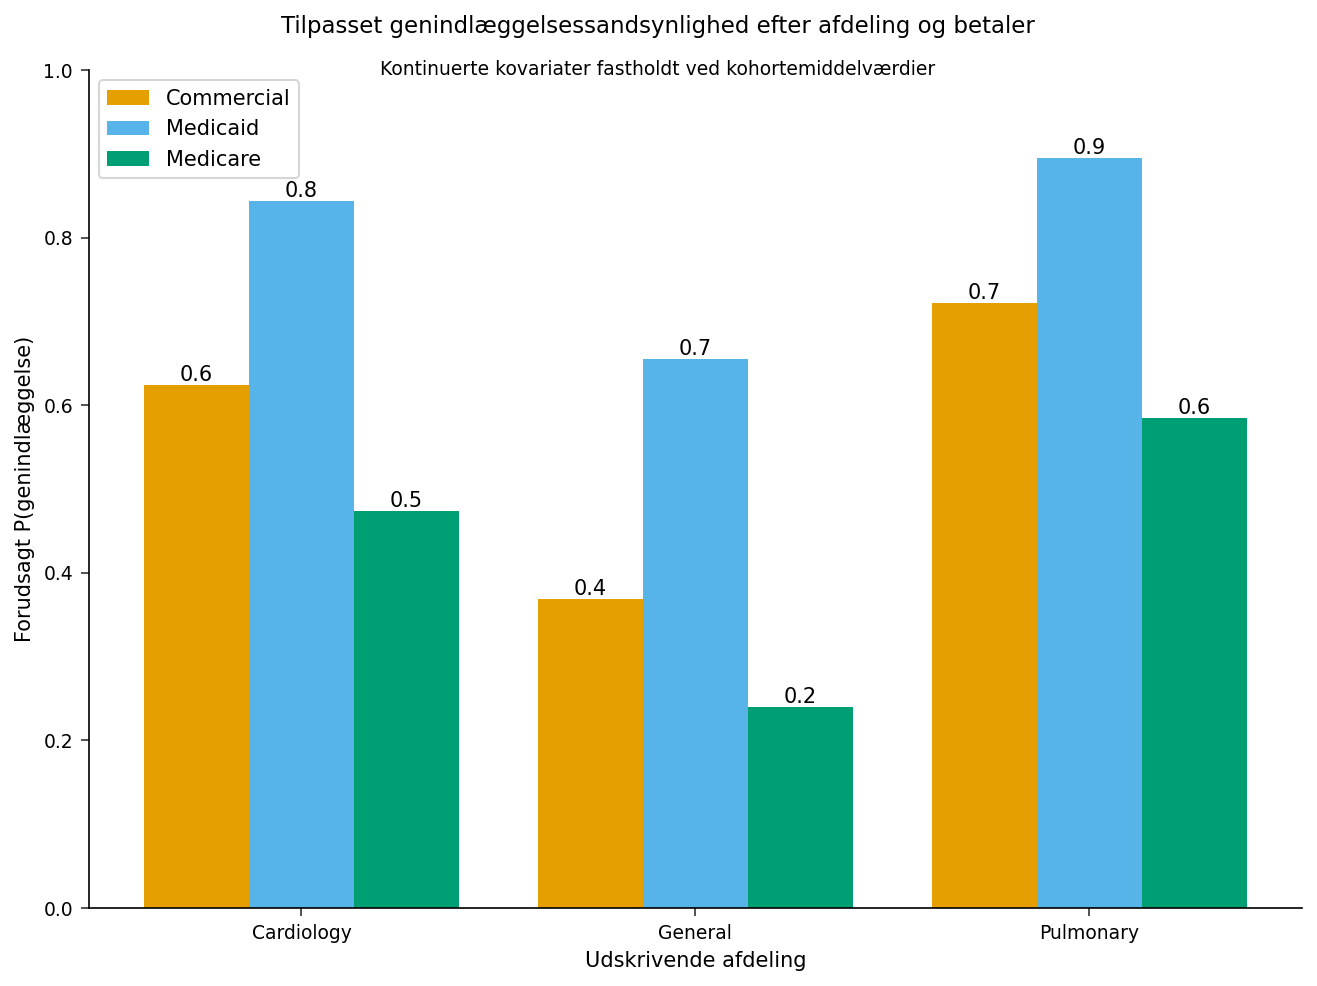

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
data grid_dx;
    LÆNGDE dept $12 payer $12;
    GØR dept = 'Cardiology', 'Pulmonary', 'General';
        GØR payer = 'Medicare', 'Medicaid', 'Commercial';
            UDDATA;
        SLUT;
    SLUT;
KØR;

data fit_dx;
    SÆT grid_dx;
    HVIS _n_ = 1 SÅ SÆT params;
    BEHOLD_VÆRDI b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    BEHOLD dept payer phat;
KØR;

PROCEDURE SGPLOT data=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITEL  "Tilpasset genindlæggelsessandsynlighed efter afdeling og betaler";
    title2 "Kontinuerte kovariater fastholdt ved kohortemiddelværdier";
    XAXIS MÆRKAT="Udskrivende afdeling";
    YAXIS MÆRKAT="Forudsagt P(genindlæggelse)" VALUES=(0 TIL 1 EFTER 0.2);
KØR;
TITEL;


## Trin 8 — Fortolkning af resultaterne

Effektplottene omdanner den tilpassede PROC LOGISTIC-model til billeder på sandsynlighedsskalaen, der kobler til care-management-beslutninger:

- **Indlæggelseslængde (tilpasningskurve).** For en Medicare-kardiologisk patient på kohortemidlerne stiger den forudsagte genindlæggelsessandsynlighed fra omkring **0.23 ved et 1-dags ophold til cirka 0.82 ved 10 dage og ~0.98 ved 18 dage** — den stejle midte af den logistiske kurve. Dette er det samme signal som odds-ratioen for indlæggelseslængde på **1.36 pr. dag** (`UNITS los=5` omskalerer den til et fem-dages trin), og det markerer lange indeksophold som en konkret udløser for indskrivning i overgangspleje.
- **Alder og betaler (sliced fit).** Risikoen stiger monotont med alderen på tværs af alle betalere, og de tre kurver krydser aldrig hinanden: **Medicaid**-kurven ligger højest ved enhver given alder, **Commercial** i midten og **Medicare** lavest — i overensstemmelse med de tilpassede betaler-odds-ratioer (Medicaid 6.02, Commercial 1.85, begge i forhold til Medicare). Gabet er størst ved yngre aldre og indsnævres, efterhånden som alle nærmer sig høj sandsynlighed, hvilket retter care-management-opmærksomheden mod yngre Medicaid-patienter, der ellers ville se lavrisiko ud.
- **Afdeling og betaler (interaktionsvisning).** **Pulmonary** bærer den højeste forudsagte genindlæggelsessandsynlighed i hver betalergruppe, **Cardiology** er mellemliggende, og **General medicine** er lavest (de tilpassede afdelings-odds-ratioer er 0.64 for Cardiology og 0.22 for General, i forhold til Pulmonary). Fordi modellen ikke har noget afdeling-efter-betaler-interaktionsled, er betalerrækkefølgen den samme additive forskydning inden for hvert serviceområde — søjlerne stiger i den samme Medicaid > Commercial > Medicare-rækkefølge i hver afdeling.

**Pointe:** i stedet for at bede klinikere om at fortolke log-odds-koefficienter præsenterer modelbaserede effektplot den tilpassede genindlæggelsesmodel som billeder på sandsynlighedsskalaen — hvem der skal indskrives i overgangsplejeopfølgning, og hvilke serviceområder og betalerpopulationer der skal prioriteres. SAS producerer disse direkte via `EFFECTPLOT`; her rekonstruerede vi de identiske kurver ud fra de tilpassede koefficienter, så eksemplet kører fra ende til anden i dag.